# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

# Rating and Sales data

**Tables** 
- `rpa_rvw_amz_monthly_rating` (monthly)
- `amz_vc_all_collct_tmp1` (weekly)

## Join tables

In [3]:
df_rating = pd.read_csv('./rawdata/rpa_rvw_amz_monthly_rating.csv')
df_rating['year_month'] = [pd.to_datetime(str(yr_month),format="%Y%m") for yr_month in df_rating.yr_month]
df_rating.drop('yr_month',axis=1,inplace=True)

In [4]:
df_rating.sort_values(by=['collection','sku','year_month'])

,sku,category,collection,abbre,allRatingCount,fiveRatingCount,fourRatingCount,threeRatingCount,twoRatingCount,oneRatingCount,...,lag1_month_three_cnt,lag1_month_two_cnt,lag1_month_one_cnt,lag2_month_all_cnt,lag2_month_five_cnt,lag2_month_four_cnt,lag2_month_three_cnt,lag2_month_two_cnt,lag2_month_one_cnt,year_month
6804,ZU-ABS-9QS,Box Springs,ABS,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-01
8389,ZU-ABS-9QS,Box Springs,ABS,NaN,6,5,0,0,0,1,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-05-01
13990,ZU-ABS-9QS,Box Springs,ABS,NaN,13,12,0,0,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-06-01
6062,ZU-ABS-9TS,Box Springs,ABS,NaN,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-01
13508,ZU-ABS-9TS,Box Springs,ABS,NaN,2,0,0,1,0,1,...,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,ZU-USLMC2B-SET,Furniture,NaN,Thompson Chise,2,2,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-02-01
9909,ZU-USLMC2B-SET,Furniture,NaN,Thompson Chise,2,2,0,0,0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-03-01
11426,ZU-USLMC2B-SET,Furniture,NaN,Thompson Chise,3,2,1,0,0,0,...,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2022-04-01
12426,ZU-USLMC2B-SET,Furniture,NaN,Thompson Chise,3,2,1,0,0,0,...,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2022-05-01


In [5]:
df_rating.set_index(['collection','sku','year_month'],inplace=True)


In [6]:
df_rating

,,,category,abbre,allRatingCount,fiveRatingCount,fourRatingCount,threeRatingCount,twoRatingCount,oneRatingCount,pdt_rating,category_order,...,lag1_month_four_cnt,lag1_month_three_cnt,lag1_month_two_cnt,lag1_month_one_cnt,lag2_month_all_cnt,lag2_month_five_cnt,lag2_month_four_cnt,lag2_month_three_cnt,lag2_month_two_cnt,lag2_month_one_cnt
collection,sku,year_month,,,,,,,,,,,,,,,,,,,,,
OLB ASB,OLB-ASB-T,2021-06-01,SmartBases,ETA SB,3520,2665,439,176,77,163,NaN,3,...,423.0,169.0,76.0,158.0,NaN,NaN,NaN,NaN,NaN,NaN
OLB DT,OLB-DT-5524,2021-06-01,Furniture,Soho Dining Table,1063,855,113,31,27,37,NaN,9,...,112.0,31.0,27.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN
OLB MBBF,OLB-MBBF-6K,2022-04-01,Frames for Mattresses,Platforma (Wood),1592,1309,169,53,14,47,4.7,5,...,140.0,45.0,12.0,37.0,1324.0,1092.0,139.0,45.0,12.0,36.0
GTFT,AZ-GTFT-300Q,2021-11-01,Toppers,GT,578,370,102,39,26,41,4.4,8,...,103.0,39.0,26.0,40.0,570.0,362.0,102.0,39.0,26.0,41.0
ASMPCH,AZ-ASMPCH-15Q,2021-08-01,Frames for Mattresses,Metal Bed w Upholstered HB,2785,2265,338,93,29,60,NaN,5,...,322.0,91.0,29.0,58.0,2599.0,2115.0,311.0,88.0,29.0,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ASMPH,AZ-ASMPH-20T,2021-10-01,Frames for Mattresses,2000H,947,733,137,42,9,26,NaN,5,...,137.0,42.0,9.0,26.0,927.0,718.0,133.0,42.0,9.0,25.0
OLB PWPBBE,OLB-PWPBBE-12K,2021-06-01,Frames for Mattresses,"Deluxe Wood, Espresso",848,712,81,16,12,27,NaN,5,...,78.0,14.0,12.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN
GTFT,AZ-GTFT-300K,2022-06-01,Toppers,GT,355,233,49,35,12,26,4.4,8,...,48.0,35.0,11.0,26.0,345.0,225.0,48.0,35.0,11.0,26.0


In [7]:
df_bsr_sales = pd.read_csv('./rawdata/amz_vc_all_collct_tmp1.csv')
df_bsr_sales['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df_bsr_sales.yr_wk]
df_bsr_sales.drop('yr_wk',axis=1,inplace=True)

df_sales_tmp = df_bsr_sales.groupby(by=['collection','sku','year_week']).mean().reset_index(['collection','sku'])
df_sales = df_sales_tmp.groupby(['collection','sku']).resample('MS').mean().reset_index(['collection','sku'])

COLLECTIONs = df_sales.collection.unique()
SKUs = df_sales.sku.unique()

df_sales.index.name = 'year_month'
df_sales.reset_index(inplace=True)
df_sales.set_index(['collection','sku','year_month'],inplace=True)
df_sales

ord_rev    ord_qty    sale_rank  \
collection sku         year_month                                         
ASMP       ASMPW-10F   2021-06-01  10446.750000  70.250000   634.250000   
                       2021-07-01   6367.350000  42.500000   358.750000   
                       2021-08-01   9872.160000  66.000000   352.200000   
                       2021-09-01    800.695000   5.250000  2618.500000   
                       2021-10-01   2213.432000  14.600000  1580.800000   
...                                         ...        ...          ...   
SWPBBHW    SWPBBHW-12T 2022-01-01      0.000000   0.000000  1666.200000   
                       2022-02-01      0.000000   0.000000  2024.000000   
                       2022-03-01     98.083333   0.333333  1991.666667   
                       2022-04-01    147.225000   0.500000  1658.750000   
                       2022-05-01     98.150000   0.333333  2210.333333   

                                    avg_price           gv  cnvrsn_rate  \
collection sku         year_month                                         
ASMP       ASMPW-10F   2021-06-01  145.600000  2620.250000     0.034434   
                       2021-07-01  149.854412  1596.000000     0.026343   
                       2021-08-01  149.081538  2141.800000     0.030115   
                       2021-09-01  160.506667   225.250000     0.016647   
                       2021-10-01  148.585000   576.200000     0.047047   
...                                       ...          ...          ...   
SWPBBHW    SWPBBHW-12T 2022-01-01         NaN     0.000000          NaN   
                       2022-02-01         NaN     0.000000          NaN   
                       2022-03-01  294.250000     8.000000     0.041667   
                       2022-04-01  294.450000     2.750000     0.181818   
                       2022-05-01  294.450000    20.666667     0.014706   

                                   rep_oos  
collection sku         year_month           
ASMP       ASMPW-10F   2021-06-01      0.0  
                       2021-07-01      0.0  
                       2021-08-01      0.0  
                       2021-09-01      0.0  
                       2021-10-01      0.0  
...                                    ...  
SWPBBHW    SWPBBHW-12T 2022-01-01      NaN  
                       2022-02-01      NaN  
                       2022-03-01      0.0  
                       2022-04-01      0.0  
                       2022-05-01      0.0  

[15257 rows x 7 columns]

In [8]:
df_all = df_sales.join(df_rating)
df_all

ord_rev    ord_qty    sale_rank  \
collection sku         year_month                                         
ASMP       ASMPW-10F   2021-06-01  10446.750000  70.250000   634.250000   
                       2021-07-01   6367.350000  42.500000   358.750000   
                       2021-08-01   9872.160000  66.000000   352.200000   
                       2021-09-01    800.695000   5.250000  2618.500000   
                       2021-10-01   2213.432000  14.600000  1580.800000   
...                                         ...        ...          ...   
SWPBBHW    SWPBBHW-12T 2022-01-01      0.000000   0.000000  1666.200000   
                       2022-02-01      0.000000   0.000000  2024.000000   
                       2022-03-01     98.083333   0.333333  1991.666667   
                       2022-04-01    147.225000   0.500000  1658.750000   
                       2022-05-01     98.150000   0.333333  2210.333333   

                                    avg_price           gv  cnvrsn_rate  \
collection sku         year_month                                         
ASMP       ASMPW-10F   2021-06-01  145.600000  2620.250000     0.034434   
                       2021-07-01  149.854412  1596.000000     0.026343   
                       2021-08-01  149.081538  2141.800000     0.030115   
                       2021-09-01  160.506667   225.250000     0.016647   
                       2021-10-01  148.585000   576.200000     0.047047   
...                                       ...          ...          ...   
SWPBBHW    SWPBBHW-12T 2022-01-01         NaN     0.000000          NaN   
                       2022-02-01         NaN     0.000000          NaN   
                       2022-03-01  294.250000     8.000000     0.041667   
                       2022-04-01  294.450000     2.750000     0.181818   
                       2022-05-01  294.450000    20.666667     0.014706   

                                   rep_oos               category      abbre  \
collection sku         year_month                                              
ASMP       ASMPW-10F   2021-06-01      0.0  Frames for Mattresses       2000   
                       2021-07-01      0.0  Frames for Mattresses       2000   
                       2021-08-01      0.0  Frames for Mattresses       2000   
                       2021-09-01      0.0  Frames for Mattresses       2000   
                       2021-10-01      0.0  Frames for Mattresses       2000   
...                                    ...                    ...        ...   
SWPBBHW    SWPBBHW-12T 2022-01-01      NaN  Frames for Mattresses  Tricia PB   
                       2022-02-01      NaN  Frames for Mattresses  Tricia PB   
                       2022-03-01      0.0  Frames for Mattresses  Tricia PB   
                       2022-04-01      0.0  Frames for Mattresses  Tricia PB   
                       2022-05-01      0.0  Frames for Mattresses  Tricia PB   

                                   allRatingCount  ...  lag1_month_four_cnt  \
collection sku         year_month                  ...                        
ASMP       ASMPW-10F   2021-06-01             0.0  ...                  NaN   
                       2021-07-01             6.0  ...                  0.0   
                       2021-08-01            20.0  ...                  1.0   
                       2021-09-01            34.0  ...                  3.0   
                       2021-10-01            41.0  ...                  4.0   
...                                           ...  ...                  ...   
SWPBBHW    SWPBBHW-12T 2022-01-01            30.0  ...                  4.0   
                       2022-02-01            31.0  ...                  4.0   
                       2022-03-01            31.0  ...                  4.0   
                       2022-04-01            31.0  ...                  4.0   
                       2022-05-01            32.0  ...                  4.0   

                   

In [9]:
df_all.loc[(COLLECTIONs[0],SKUs[0],slice(None))]

ord_rev  ord_qty    sale_rank   avg_price  \
collection sku       year_month                                                 
ASMP       ASMPW-10F 2021-06-01  10446.7500    70.25   634.250000  145.600000   
                     2021-07-01   6367.3500    42.50   358.750000  149.854412   
                     2021-08-01   9872.1600    66.00   352.200000  149.081538   
                     2021-09-01    800.6950     5.25  2618.500000  160.506667   
                     2021-10-01   2213.4320    14.60  1580.800000  148.585000   
                     2021-11-01      0.0000     0.00          NaN         NaN   
                     2021-12-01      0.0000     0.00          NaN         NaN   
                     2022-01-01      0.0000     0.00          NaN         NaN   
                     2022-02-01         NaN      NaN          NaN         NaN   
                     2022-03-01   4517.5000    32.50   937.500000  139.000000   
                     2022-04-01   7186.8675    51.50   271.750000  139.567350   
                     2022-05-01   6524.1800    46.00   329.666667  141.830000   

                                          gv  cnvrsn_rate  rep_oos  \
collection sku       year_month                                      
ASMP       ASMPW-10F 2021-06-01  2620.250000     0.034434      0.0   
                     2021-07-01  1596.000000     0.026343      0.0   
                     2021-08-01  2141.800000     0.030115      0.0   
                     2021-09-01   225.250000     0.016647      0.0   
                     2021-10-01   576.200000     0.047047      0.0   
                     2021-11-01     0.000000          NaN      0.0   
                     2021-12-01     0.000000          NaN      NaN   
                     2022-01-01     0.000000          NaN      0.0   
                     2022-02-01          NaN          NaN      NaN   
                     2022-03-01   916.500000     0.035424      0.0   
                     2022-04-01  1728.000000     0.029825      0.0   
                     2022-05-01  1781.333333     0.026231      0.0   

                                              category abbre  allRatingCount  \
collection sku       year_month                                                
ASMP       ASMPW-10F 2021-06-01  Frames for Mattresses  2000             0.0   
                     2021-07-01  Frames for Mattresses  2000             6.0   
                     2021-08-01  Frames for Mattresses  2000            20.0   
                     2021-09-01  Frames for Mattresses  2000            34.0   
                     2021-10-01  Frames for Mattresses  2000            41.0   
                     2021-11-01  Frames for Mattresses  2000            49.0   
                     2021-12-01  Frames for Mattresses  2000            53.0   
                     2022-01-01  Frames for Mattresses  2000            54.0   
                     2022-02-01  Frames for Mattresses  2000            55.0   
                     2022-03-01  Frames for Mattresses  2000            56.0   
                     2022-04-01  Frames for Mattresses  2000            58.0   
                     2022-05-01  Frames for Mattresses  2000            65.0   

                                 ...  lag1_month_four_cnt  \
collection sku       year_month  ...                        
ASMP       ASMPW-10F 2021-06-01  ...                  NaN   
                     2021-07-01  ...                  0.0   
                     2021-08-01  ...                  1.0   
                     2021-09-01  ...                  3.0   
                     2021-10-01  ...                  4.0   
                     2021-11-01  ...                  4.0   
                     2021-12-01  ...                  5.0   
                     2022-01-01  ...                  5.0   
                     2022-02-01  ...                  5.0   
                     2022-03-01  ...                  5.0   
                     2022-04-01  ...                  5.0   
      

## Count statistics (no NA removal)

In [18]:
df_all_count = df_all.reset_index().groupby(['collection','sku']).agg({'year_month':'count'})
df_all_count

year_month
collection sku                    
ASMP       ASMPW-10F            12
           ASMPW-10K            12
           ASMPW-10Q            12
           ASMPW-10T            12
           ASMPW-15F            12
...                            ...
SWPBBHG    SWPBBHG-12T          29
SWPBBHW    SWPBBHW-12F          29
           SWPBBHW-12K          29
           SWPBBHW-12Q          29
           SWPBBHW-12T          29

[640 rows x 1 columns]

In [19]:
df_all_count.describe()

,year_month
count,640.000000
mean,23.839063
std,8.546881
min,1.000000
25%,20.000000
50%,29.000000
75%,29.000000
max,29.000000


## Count statistics (with drop NA)

In [20]:
# dropna !
df_all_count = df_all.dropna().reset_index().groupby(['collection','sku']).agg({'year_month':'count'})
df_all_count

year_month
collection sku                    
ASMP       ASMPW-10K            10
           ASMPW-10T            10
           ASMPW-15K             5
           ASMPW-15NT           10
           ASMPW-15Q             3
...                            ...
SWPBBHG    SWPBBHG-12F           4
           SWPBBHG-12K           4
           SWPBBHG-12Q           4
SWPBBHW    SWPBBHW-12K           5
           SWPBBHW-12T           3

[426 rows x 1 columns]

In [13]:
df_all_count.describe()

,year_month
count,426.000000
mean,6.225352
std,3.282168
min,1.000000
25%,4.000000
50%,5.000000
75%,10.000000
max,12.000000


In [23]:
df_all_tmp = df_all_count.reset_index()
sku_gt20 = df_all_tmp[df_all_tmp.year_month > 11].sku.to_list()
len(sku_gt20)

18

In [24]:
sku_gt20

['AZ-ASMP-15F',
 'AZ-ASMP-15K',
 'AZ-ASMP-15Q',
 'AZ-ASMP-15T',
 'AZ-FMS-5T',
 'FSPB-F',
 'FSPB-K',
 'FSPB-LB-F',
 'FSPB-LB-K',
 'FSPB-LB-Q',
 'FSPB-Q',
 'OLB-ABS-5CK',
 'OLB-ABS-5F',
 'OLB-ABS-5K',
 'OLB-ABS-5Q',
 'OLB-ABS-5T',
 'OLB-ABS-5TXL',
 'OLB-BNSM-6T']

## Linear models

In [27]:
tmp_df = df_bsr_sales.copy()
tmp_df.sort_values(by=['asin','year_week'],inplace=True)
tmp_df

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,sku,collection,year_week
3032,B004TMI746,Night Therapy Memory Foam 8 Inch Therapeutic C...,860.19,6,303.0,143.365000,159.0,0.037736,0.0,SC-BTCM-8T,BTCM,2020-01-05
3047,B004TMI746,Night Therapy Memory Foam 8 Inch Therapeutic C...,1870.10,13,326.0,143.853846,270.0,0.048148,0.0,SC-BTCM-8T,BTCM,2020-01-12
3073,B004TMI746,Night Therapy Memory Foam 8 Inch Therapeutic C...,1808.35,13,297.0,139.103846,1644.0,0.007908,0.0,SC-BTCM-8T,BTCM,2020-01-19
3071,B004TMI746,Night Therapy Memory Foam 8 Inch Therapeutic C...,1453.60,11,226.0,132.145454,2449.0,0.004492,0.0,SC-BTCM-8T,BTCM,2020-01-26
3055,B004TMI746,Night Therapy Memory Foam 8 Inch Therapeutic C...,1409.90,10,233.0,140.990000,317.0,0.031546,0.0,SC-BTCM-8T,BTCM,2020-02-02
...,...,...,...,...,...,...,...,...,...,...,...,...
60510,B09N92HXN3,ZINUS Tucker Bamboo and Metal Platform Bed Fra...,0.00,0,2934.0,NaN,0.0,NaN,NaN,ZU-FBOBH2-14T,FBOBH2,2022-04-03
52639,B09N92HXN3,ZINUS Tucker Bamboo and Metal Platform Bed Fra...,167.78,1,2826.0,167.780000,9.0,0.111111,0.0,ZU-FBOBH2-14T,FBOBH2,2022-04-17
60508,B09N92HXN3,ZINUS Tucker Bamboo and Metal Platform Bed Fra...,0.00,0,2826.0,NaN,0.0,NaN,NaN,ZU-FBOBH2-14T,FBOBH2,2022-04-24
52638,B09N92HXN3,ZINUS Tucker Bamboo and Metal Platform Bed Fra...,167.78,1,2971.0,167.780000,11.0,0.090909,0.0,ZU-FBOBH2-14T,FBOBH2,2022-05-01


In [56]:
predictors = ['Intercept','sale_rank','avg_price','cnvrsn_rate','rep_oos','gv']
cols = predictors + ['p_'+x for x in predictors] + ['R2','model']
df_ols_all = pd.DataFrame(columns=cols,index=sku_gt20)

for sku in sku_gt20:
    tmp_df_sku = tmp_df[tmp_df.sku==sku]
    
    model = sm.OLS.from_formula("ord_rev ~ sale_rank+avg_price+cnvrsn_rate+rep_oos+gv", data=tmp_df_sku)
    result = model.fit()
    tmp_ols = result.summary().tables[1].data

    coeffs = list()
    p_coeffs = list()
    for k in range(len(predictors)):
        coeffs.append(float(tmp_ols[k+1][1])) # Coefficients
        p_coeffs.append(float(tmp_ols[k+1][4])) # P > |t|
    coeffs.extend(p_coeffs)
    
    r2 = [float(result.summary().tables[0].data[0][-1])] # R-squrared
    coeffs.extend(r2)
    coeffs.extend([model])
    df_ols_all.loc[sku] = coeffs
    
    print(f"model rank : %d" %model.rank)
    del tmp_df_sku, tmp_ols, result, coeffs, p_coeffs, r2

model rank : 6
model rank : 6
model rank : 6
model rank : 6
model rank : 6
model rank : 5
model rank : 6
model rank : 6
model rank : 6
model rank : 6
model rank : 5
model rank : 6
model rank : 5
model rank : 6
model rank : 6
model rank : 5
model rank : 6
model rank : 6


/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


In [54]:
df_ols_all

,Intercept,sale_rank,avg_price,cnvrsn_rate,rep_oos,gv,p_Intercept,p_sale_rank,p_avg_price,p_cnvrsn_rate,p_rep_oos,p_gv,R2,model
AZ-ASMP-15F,-31730.0,14.355,182.3391,429200.0,14160.0,2.7055,0.0,0.014,0.0,0.0,0.532,0.0,0.814,<statsmodels.regression.linear_model.OLS objec...
AZ-ASMP-15K,-9636.9132,5.6062,30.4029,104700.0,-2810.8321,4.8965,0.0,0.003,0.0,0.0,0.01,0.0,0.958,<statsmodels.regression.linear_model.OLS objec...
AZ-ASMP-15Q,-7001.3156,-6.2748,13.2405,317200.0,-4470.5495,3.0789,0.114,0.207,0.634,0.0,0.055,0.0,0.856,<statsmodels.regression.linear_model.OLS objec...
AZ-ASMP-15T,-7948.727,7.4514,17.6769,194800.0,-3243.6136,1.9529,0.0,0.003,0.216,0.0,0.003,0.0,0.882,<statsmodels.regression.linear_model.OLS objec...
AZ-FMS-5T,-34390.0,20.6789,161.426,6890.1499,7960.4697,9.0233,0.0,0.006,0.0,0.241,0.012,0.0,0.908,<statsmodels.regression.linear_model.OLS objec...
FSPB-F,-22220.0,1.6398,47.0076,582500.0,0.0,3.9464,0.0,0.048,0.0,0.0,NaN,0.0,0.923,<statsmodels.regression.linear_model.OLS objec...
FSPB-K,-7796.8987,-3.8584,7.3973,602300.0,-1925.9249,3.124,0.0,0.329,0.043,0.0,0.818,0.0,0.938,<statsmodels.regression.linear_model.OLS objec...
FSPB-LB-F,3502.366,-0.6894,-11.7671,173900.0,-2606.5338,0.9712,0.02,0.001,0.019,0.0,0.426,0.0,0.65,<statsmodels.regression.linear_model.OLS objec...
FSPB-LB-K,1144.2557,0.2568,-4.5158,84130.0,-6857.1957,2.3897,0.301,0.423,0.069,0.0,0.304,0.0,0.523,<statsmodels.regression.linear_model.OLS objec...
FSPB-LB-Q,-3703.7504,-0.3979,3.0966,247900.0,-3574.1083,3.0297,0.034,0.469,0.544,0.0,0.0,0.0,0.801,<statsmodels.regression.linear_model.OLS objec...


<AxesSubplot:>

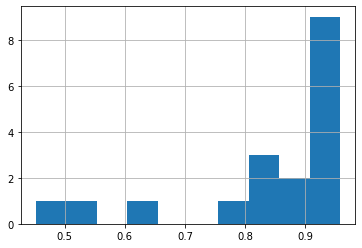

In [61]:
df_ols_all.R2.hist()

# Conclusion

Need more samples, or weekly data to draw some conclusion
* Number of samples are too low to get models : less than 12 samples
* There are some SKUs having R2 greater than $0.9$